### Private SLI Predictions



In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np

df = pd.read_csv("data.csv")

df = df[df['Public Service Line Material'].isin(['LEAD', 'NOT LEAD'])]

# Convert target variable to binary values
df['Public Service Line Material'] = df['Public Service Line Material'].map({'LEAD': 1, 'NOT LEAD': 0})


categorical_features = [
    'Wall Material', 'Roof Material', 'Basement', 'Basement Finish', 
    'Central Air Conditioning', 'Garage 1 Material','Garage 1 Size', 'Garage 1 Attached', 
    'Use', 'Type of Residence', 'Flood Risk Factor', 'withinmr100',
     'school_elem_district', 'school_hs_district', 'township_name', 'Central Heating', 'FEMA Floodplain', 'Repair Condition', 'withinmr101300'
]
#removed based on control: Central Heating, FEMA Floodplain, Repair Condition, within101300, 'Bedrooms', 'Fireplaces'
#removed based on low correlation: 'Tax Rate', 
numerical_features = [
    'Land Square Feet', 'Age', 'Rooms', 'Full Baths',
    'Half Baths', 'Garage 1 Area', 'Building Square Feet', 'longitude',
    'latitude', 'tract_pop', 'tract_white_perc', 'tract_black_perc', 'tract_asian_perc', 'tract_his_perc',
    'tract_other_perc', 'Tract Median Income', 'Bedrooms', 'Fireplaces'
]
#random noise
np.random.seed(0)
df['random_noise'] = np.random.rand(len(df))
numerical_features.append('random_noise')

#Numerical: Fill missing values with median (and scale?)
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
   # ('scaler', StandardScaler())
])

#Categorical: Fill missing values with the most frequent value & one-hot encode
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

#Combine Transformers into ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, numerical_features),
    ('cat', cat_transformer, categorical_features)
])



X = df.drop(columns=['Public Service Line Material'])
y = df['Public Service Line Material']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)


X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing complete.")

Preprocessing complete.


## Get Counts 

In [2]:
print("Training set distribution:")
print(y_train.value_counts())
print()

print("Test set distribution:")
print(y_test.value_counts())

Training set distribution:
Public Service Line Material
1    36965
0    26638
Name: count, dtype: int64

Test set distribution:
Public Service Line Material
1    9241
0    6660
Name: count, dtype: int64


# Train Classifier

In [3]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Train a baseline Random Forest model
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,            # Limit depth of trees
    class_weight='balanced',
    min_samples_split=10,    # Increase minimum samples needed to split a node
    min_samples_leaf=5,      # Increase minimum samples in leaf nodes
    max_features='sqrt',     # Consider a subset of features for splitting
    random_state=0,
    n_jobs=-1
)
rf.fit(X_train_processed, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, n_jobs=-1, random_state=42)

# Get Classifier Results


Training Set Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.82      0.87     26638
           1       0.88      0.95      0.91     36965

    accuracy                           0.89     63603
   macro avg       0.90      0.88      0.89     63603
weighted avg       0.90      0.89      0.89     63603


Testing Set Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.81      0.85      6660
           1       0.87      0.93      0.90      9241

    accuracy                           0.88     15901
   macro avg       0.89      0.87      0.88     15901
weighted avg       0.88      0.88      0.88     15901



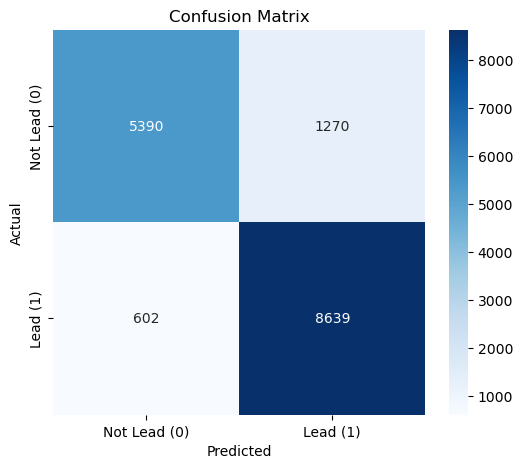

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns


# Predictions on training set
y_train_pred = rf.predict(X_train_processed)
print("\nTraining Set Classification Report:")
print(classification_report(y_train, y_train_pred))

# Predictions on test set
y_test_pred = rf.predict(X_test_processed)
print("\nTesting Set Classification Report:")
print(classification_report(y_test, y_test_pred))
# Confusion Matrix
y_pred = rf.predict(X_test_processed)

conf_matrix = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Not Lead (0)', 'Lead (1)'],
            yticklabels=['Not Lead (0)', 'Lead (1)'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Plot ROC Curve

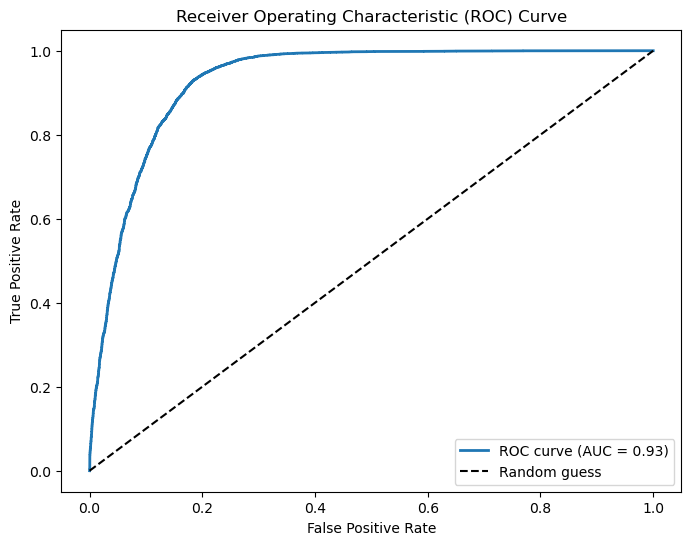

In [5]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_test_proba = rf.predict_proba(X_test_processed)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

roc_auc = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})", lw=2)
plt.plot([0, 1], [0, 1], 'k--', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.show()

In [6]:
import numpy as np

# Get the feature index of 'num__Age' after preprocessing
feature_names = preprocessor.get_feature_names_out()
age_index = np.where(feature_names == 'num__Age')[0][0]

# Count how often 'Age' is used to split across all trees
split_counts = []

for tree in rf.estimators_:
    tree_feature_indices = tree.tree_.feature
    # -2 indicates a leaf node
    split_count = np.sum(tree_feature_indices == age_index)
    split_counts.append(split_count)

total_age_splits = np.sum(split_counts)
avg_age_splits_per_tree = np.mean(split_counts)

print(f"'Age' was used in {total_age_splits} split(s) across all trees.")
print(f"Average splits per tree: {avg_age_splits_per_tree:.2f}")

'Age' was used in 7020 split(s) across all trees.
Average splits per tree: 35.10


In [7]:
import numpy as np
from collections import Counter

# Get the feature index of 'num__Age' after preprocessing
feature_names = preprocessor.get_feature_names_out()
age_index = np.where(feature_names == 'num__Age')[0][0]

# Count how often 'Age' is used to split across all trees
split_counts = []

for tree in rf.estimators_:
    tree_feature_indices = tree.tree_.feature
    # -2 indicates a leaf node
    split_count = np.sum(tree_feature_indices == age_index)
    split_counts.append(split_count)

# Count frequencies of each split count
split_count_freq = Counter(split_counts)
most_common_split_count, frequency = split_count_freq.most_common(1)[0]

total_age_splits = np.sum(split_counts)


print(f"Most common number of 'Age' splits per tree: {most_common_split_count}")

'Age' was used in 7020 split(s) across all trees.
Most common number of 'Age' splits per tree: 38 (occurred in 14 tree(s))


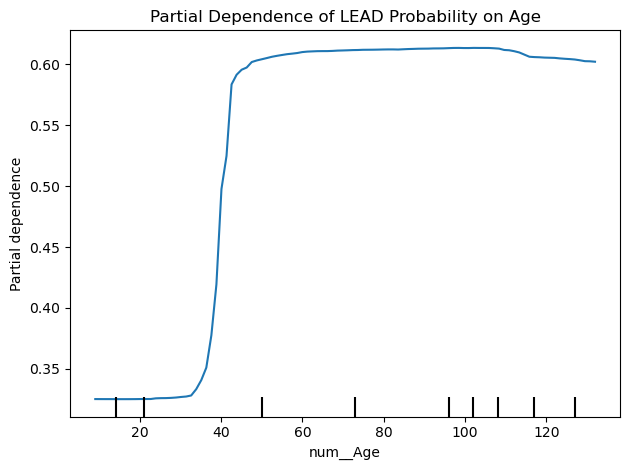

In [8]:
from sklearn.inspection import PartialDependenceDisplay

age_index = np.where(preprocessor.get_feature_names_out() == 'num__Age')[0][0]

PartialDependenceDisplay.from_estimator(
    rf, X_train_processed, features=[age_index],
    feature_names=preprocessor.get_feature_names_out(),
    kind='average', grid_resolution=100
)
plt.title("Partial Dependence of LEAD Probability on Age")
plt.tight_layout()
plt.show()

/var/folders/z4/gnmh6c053_320_y589_vnxk00000gn/T/ipykernel_45879/3632370042.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lead_rate_by_age = df_binned.groupby('Age_Bin')['Lead_Binary'].mean()


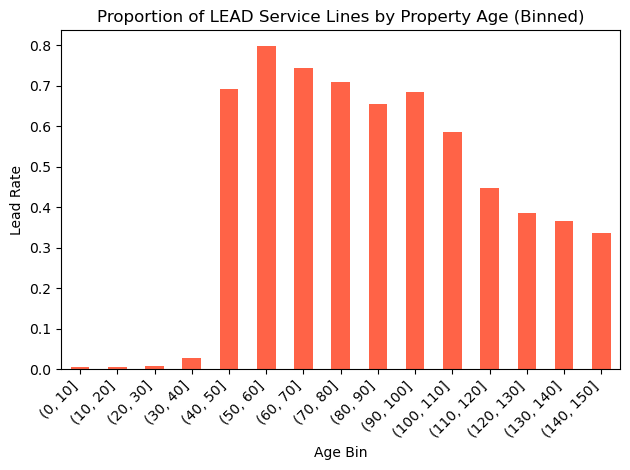

In [9]:
df_binned = df[df['Private Service Line Material'].isin(['LEAD', 'NOT LEAD'])].copy()
df_binned['Lead_Binary'] = df_binned['Private Service Line Material'].map({'LEAD': 1, 'NOT LEAD': 0})
df_binned['Age_Bin'] = pd.cut(df_binned['Age'], bins=np.arange(0, 160, 10))

lead_rate_by_age = df_binned.groupby('Age_Bin')['Lead_Binary'].mean()

lead_rate_by_age.plot(kind='bar', color='tomato')
plt.title("Proportion of LEAD Service Lines by Property Age (Binned)")
plt.ylabel("Lead Rate")
plt.xlabel("Age Bin")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()